In [84]:
pip install refinitiv-data pandas

Note: you may need to restart the kernel to use updated packages.


In [85]:
import datetime as dt
import numpy as np
import pandas as pd
import refinitiv.data as rd
import kit as kt

In [86]:
rd.open_session()

<refinitiv.data.session.Definition object at 0x11ef729f0 {name='workspace'}>

In [87]:

df_top= kt.get_top_esg_stocks()

🔄 Screening
✅ Done: 100 stock.


In [ ]:
df_top.sort_values("ESG Score", ascending=False) 

,RIC,Company Common Name,ISIN,Exchange Name,Exchange Market Identifier Code,ESG Score,Company Market Cap,Price Close
3,APAM.AS,Aperam SA,LU0569974404,Euronext Amsterdam,XAMS,92.329789,3094243619.6,42.28
1,AMA.MC,Amadeus IT Group SA,ES0109067019,BME - BOLSAS Y MERCADOS ESPANOLES,XMAD,89.593109,21569901935.400002,47.88
90,AIRP.PA,L'Air Liquide Societe Anonyme pour l'Etude et ...,FR0000120073,Paris Stock Exchange,XPAR,86.671483,97162860475.199997,167.7
43,LIGHT.AS,Signify NV,NL0011821392,Euronext Amsterdam,XAMS,86.230863,2450396268.96,19.99
67,TE.PA,Technip Energies NV,NL0014559478,Paris Stock Exchange,XPAR,82.470783,5868659493.2,32.9
...,...,...,...,...,...,...,...,...
99,JCQ.PA,Jacquet Metals SA,FR0000033904,Paris Stock Exchange,XPAR,26.014996,523226798.1,24.3
11,FGA.PA,Figeac Aero SARL,FR0011665280,Paris Stock Exchange,XPAR,17.908404,509652457.5,11.5
39,GNRO.PA,Geneuro SA,CH0308403085,Paris Stock Exchange,XPAR,17.246087,916636.7364,0.0308
26,OSE.PA,OSE Immunotherapeutics SA,FR0012127173,Paris Stock Exchange,XPAR,15.92909,98299234.512,4.376


In [89]:
rics = df_top["RIC"].tolist()


In [90]:
prices = rd.get_history(
    universe=rics,
    fields=["TR.PriceClose"],
    start="2025-01-01",
    end="2026-02-01",
    interval="daily"   # or "1D"
)

/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [91]:
df_px = prices.copy()

# If it has Instrument / Date columns
if {"Instrument", "Date", "TR.PriceClose"}.issubset(df_px.columns):
    px = df_px.pivot(index="Date", columns="Instrument", values="TR.PriceClose").sort_index()
else:
    # sometimes it already comes as a matrix
    px = df_px

rets = px.pct_change().dropna()
rets.head()

/var/folders/d3/4j2xrjxn06v329lnxwrwmzs80000gn/T/ipykernel_52107/2900408090.py:10:FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


Price Close,ABS.PA,AMA.MC,EDEN.PA,APAM.AS,DIDA.MC,DBV.PA,IDLA.PA,OCI.AS,FNAC.PA,BPOST.BR,...,AIRP.PA,DAST.PA,CAGR.PA,ADP.PA,CRIP.PA,CBLP.PA,BGBN.PA,CHBE.PA,AREIT.PA,JCQ.PA
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-03,0.008899,-0.019814,-0.01733,-0.013344,0.0,0.012403,-0.00672,0.003594,-0.007117,0.004032,...,-0.007828,-0.017523,-0.00937,-0.003565,0.0,0.007317,-0.047853,-0.012514,0.0,0.003448
2025-01-06,0.389195,0.013377,0.020575,0.018298,0.052288,-0.007657,0.016238,0.024172,0.005376,0.031627,...,0.022892,0.052891,0.010972,-0.002683,-0.003929,0.038741,-0.010309,0.028802,0.017021,0.006873
2025-01-07,0.670635,0.0,-0.02688,-0.00625,-0.006211,0.010802,-0.011984,0.006556,0.02852,-0.021898,...,0.006828,0.007886,0.001871,-0.011659,-0.003945,0.002331,0.005208,-0.020157,0.0,-0.002275
2025-01-08,-0.239905,-0.00704,0.03683,-0.008648,0.03125,0.145038,0.048518,-0.025619,-0.024263,-0.032836,...,-0.010172,-0.004636,-0.001868,-0.020871,-0.00198,-0.030233,-0.028497,0.005714,0.0,0.0
2025-01-09,0.0375,0.016248,0.010149,-0.002379,0.042424,0.533333,-0.005141,0.008913,0.005329,-0.012346,...,0.00444,0.002329,0.005614,0.011121,-0.001984,0.007194,0.0,-0.030682,0.0,0.00114


In [92]:
top_assets = (df_top
              .dropna(subset=["RIC", "Company Market Cap"])
              .sort_values("Company Market Cap", ascending=False)
              .head(60)["RIC"]
              .tolist())

rets2 = rets[top_assets].dropna(axis=1)  # giữ những mã có đủ dữ liệu


In [93]:
mu = rets2.mean() * 252
cov = rets2.cov() * 252


In [94]:
def max_sharpe_random(mu, cov, n_trials=50000, w_max=0.08, n_hold=30, seed=1):
    rng = np.random.default_rng(seed)
    assets = mu.index.tolist()
    n = len(assets)

    # ✅ force pure numpy float arrays
    mu_v = mu.to_numpy(dtype=float)
    cov_m = cov.to_numpy(dtype=float)

    best_s = -1e9
    best_w = None

    for _ in range(n_trials):
        w = rng.random(n)
        w /= w.sum()

        if (w > w_max).any():
            continue

        r = float(w @ mu_v)
        v = float(np.sqrt(w @ cov_m @ w))
        if v <= 0:
            continue

        s = r / v
        if s > best_s:
            best_s = s
            best_w = w

    if best_w is None:
        raise RuntimeError("No feasible portfolio found. Increase w_max (e.g. 0.10) or n_trials.")

    w_ser = pd.Series(best_w, index=assets).sort_values(ascending=False)
    w_ser.iloc[n_hold:] = 0.0
    w_ser = w_ser / w_ser.sum()
    return w_ser, best_s


In [95]:
w0, sharpe0 = max_sharpe_random(mu, cov, n_trials=50000, w_max=0.08, n_hold=30, seed=42)

portfolio = (w0[w0 > 0]
             .rename("weight")
             .reset_index()
             .rename(columns={"index": "RIC"})
             .sort_values("weight", ascending=False)
             .reset_index(drop=True))

portfolio.head(20), sharpe0


(         RIC    weight
 0    GREG.MC  0.048782
 1    GEST.MC  0.046540
 2    ABNd.AS  0.046083
 3    INGA.AS  0.045874
 4   CENER.BR  0.043065
 5    DIDA.MC  0.042374
 6     ADP.PA  0.042069
 7     AYV.PA  0.041793
 8   ADYEN.AS  0.040739
 9      TE.PA  0.040732
 10   ARGX.BR  0.040704
 11    UNI.MC  0.039208
 12  ANTIN.PA  0.036226
 13   EXOR.AS  0.036021
 14   JDEP.AS  0.035415
 15   APAM.AS  0.032470
 16    MRL.MC  0.029534
 17     NN.AS  0.029299
 18   BFIT.AS  0.028155
 19  DSFIR.AS  0.027171,
 2.038393853849665)

In [96]:
def build_investable_set(df_top, top_mcap=60):
    df = df_top.copy()

    ric_col = "RIC"
    mcap_col = "Company Market Cap"

    df = df.dropna(subset=[ric_col, mcap_col]).copy()
    df = df.sort_values(mcap_col, ascending=False).head(top_mcap)

    return df[ric_col].astype(str).tolist()


In [97]:
def initial_portfolio(df_top, start="2025-08-01", end="2026-02-01", top_mcap=60, n_hold=30, w_max=0.08):
    rics0 = build_investable_set(df_top, top_mcap=top_mcap)

    px = get_price_matrix(rics0, start, end)
    rets = px.pct_change().dropna()

    mu = rets.mean() * 252
    cov = rets.cov() * 252

    w = markowitz_max_sharpe(mu, cov, n_hold=n_hold, w_max=w_max)
    return w, px


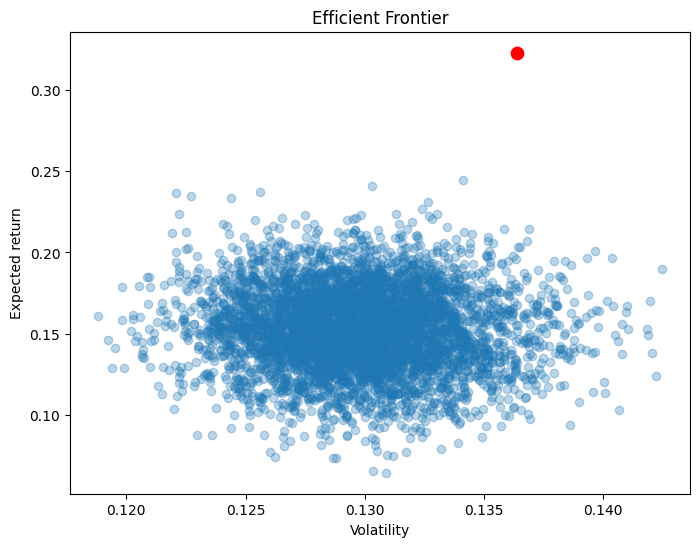

In [98]:
import matplotlib.pyplot as plt

rets_list = []
vol_list = []

for _ in range(5000):
    w = np.random.random(len(mu))
    w /= w.sum()

    r = w @ mu.to_numpy()
    v = np.sqrt(w @ cov.to_numpy() @ w)

    rets_list.append(r)
    vol_list.append(v)

plt.figure(figsize=(8,6))
plt.scatter(vol_list, rets_list, alpha=0.3)
plt.scatter(np.sqrt(w0 @ cov @ w0), w0 @ mu, color='red', s=80)
plt.xlabel("Volatility")
plt.ylabel("Expected return")
plt.title("Efficient Frontier")
plt.show()


<Axes: title={'center': 'Portfolio performance'}, xlabel='Date'>

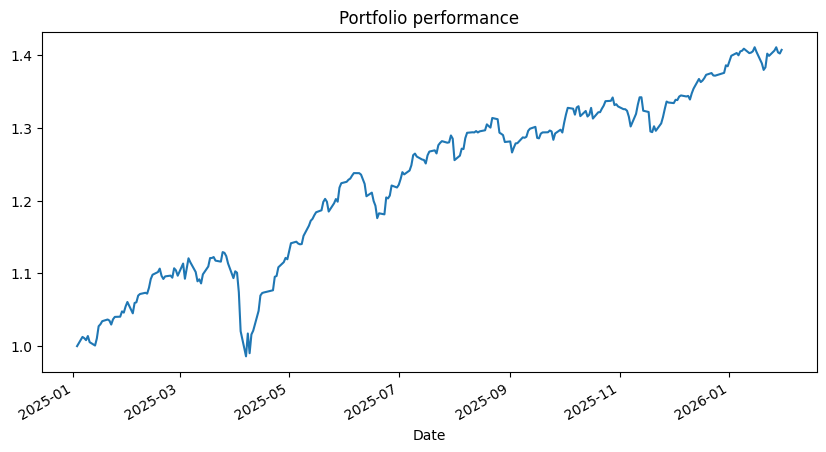

In [99]:
port_returns = (rets2 * w0).sum(axis=1)

cum = (1 + port_returns).cumprod()

cum.plot(figsize=(10,5), title="Portfolio performance")


In [100]:
port_ret = w0 @ mu
port_vol = np.sqrt(w0 @ cov @ w0)
port_sharpe = port_ret / port_vol

port_ret, port_vol, port_sharpe


(0.3228409099073478, 0.13638353777405074, 2.367154534751875)

<Axes: xlabel='Date'>

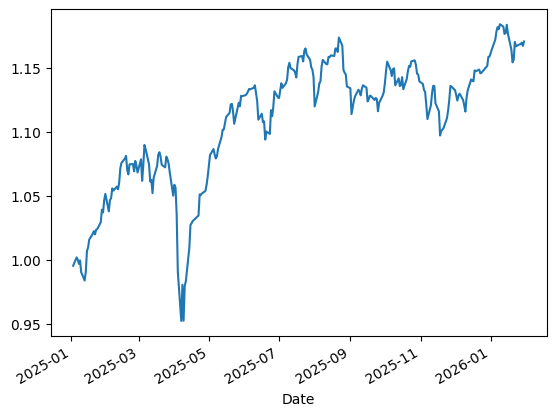

In [101]:
ew = rets2.mean(axis=1)
(1 + ew).cumprod().plot()

In [102]:
mom = px.iloc[-1] / px.iloc[-21] - 1
mom = mom.sort_values(ascending=False)

In [103]:
mom_top = mom.head(15).index

In [104]:
w_markowitz = w0 * 0.7

w_mom = pd.Series(1/len(mom_top), index=mom_top) * 0.3

w_final = w_markowitz.add(w_mom, fill_value=0)
w_final /= w_final.sum()


In [105]:
mom5 = px.iloc[-1] / px.iloc[-6] - 1
mom5 = mom5.sort_values(ascending=False)

top20 = mom5.head(20).index


In [106]:
w = pd.Series(1/len(top20), index=top20)


In [107]:
def build_momentum_portfolio(px, n=20, lookback=5):
    mom = px.iloc[-1] / px.iloc[-lookback-1] - 1
    mom = mom.sort_values(ascending=False)

    top = mom.head(n).index
    w = pd.Series(1/len(top), index=top)
    return w


In [108]:
rets2[w.index]



KeyError: "['POXEL.PA', 'FNAC.PA', 'SIFG.AS', 'OVH.PA', 'SRPG.PA', 'DOMI.MC', 'FFARM.AS', 'AREIT.PA', 'ASY.PA'] not in index"

In [ ]:
vol = rets2.std()
vol_filter = vol[vol < vol.median()].index

px_filtered = px[vol_filter]
